# Credit Score Classification - AutoML Pipeline
## Microsoft Team Data Science Process (TDSP) Template

**Project:** Credit Score Classification using AutoML  
**Date:** 2026-05-20  
**Version:** 2.0 (TDSP Format)

---

## Table of Contents
1. [Business Understanding](#1-business-understanding)
2. [Data Acquisition](#2-data-acquisition)
3. [Data Understanding](#3-data-understanding)
4. [Data Preparation](#4-data-preparation)
5. [Modeling](#5-modeling)
6. [Evaluation](#6-evaluation)
7. [Deployment](#7-deployment)

---

## 1. Business Understanding

### 1.1 Project Objectives
The goal of this project is to develop an automated machine learning solution for credit score classification. This system will:
- Classify customers into credit score categories (Poor, Standard, Good)
- Provide probability scores for risk assessment
- Enable data-driven lending decisions
- Reduce manual review time and costs

### 1.2 Success Criteria
- **Accuracy:** Achieve >70% classification accuracy
- **Precision:** Minimize false positives for high-risk categories
- **Recall:** Identify majority of poor credit scores
- **F1-Score:** Balanced performance across all classes
- **Deployment:** Model registered and ready for production use

### 1.3 Business Impact
- Improved risk assessment accuracy
- Faster loan approval process
- Reduced default rates
- Better customer segmentation

### 1.4 Key Stakeholders
- **Business:** Credit Risk Management Team
- **Technical:** Data Science & ML Engineering Teams
- **End Users:** Loan Officers & Credit Analysts

## 2. Data Acquisition

### 2.1 Data Sources
- **Source:** Delta Lake (../data/train_silver/)
- **Format:** Parquet files
- **Size:** 100,000 samples
- **Features:** 28 columns including demographic, financial, and credit history data

In [1]:
from pathlib import Path

# Find project root based on known workspace markers
def find_project_root(start_path: Path = Path.cwd()):
    markers = {'data', 'outputs', 'notebooks', 'scripts'}
    for path in [start_path, *start_path.parents]:
        if any((path / marker).exists() for marker in markers):
            return path
    raise FileNotFoundError("Project root not found from current working directory")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / 'data' / 'train_silver'
LOG_DIR = PROJECT_ROOT / 'outputs' / 'logs'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'predictions'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'
for directory in (LOG_DIR, OUTPUT_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# Configuration dictionary
CONFIG = {
    'base': {
        'project_root': str(PROJECT_ROOT),
        'data_dir': str(DATA_DIR),
        'log_dir': str(LOG_DIR),
        'output_dir': str(OUTPUT_DIR),
        'figure_dir': str(FIGURE_DIR)
    },
    'data': {
        'path': str(DATA_DIR),
        'sample_size': 100000,
        'test_size': 0.2,
        'random_state': 42,
        'target_column': 'credit_score'
    },
    'model': {
        'name': 'credit_score_classifier',
        'experiment_name': 'credit_score_automl_experiment',
        'time_budget': 120,
        'max_iter': 20,
        'cv_folds': 3,
        'estimators': ['lgbm', 'xgboost', 'rf', 'extra_tree'],
        'metric': 'accuracy'
    },
    'feature_engineering': {
        'drop_columns': ['id', 'customer_id', 'ssn'],  # High cardinality, no predictive value
        'categorical_encoding': 'auto',  # Will use target encoding for high cardinality
        'handle_missing': True
    },
    'output': {
        'predictions_file': str(OUTPUT_DIR / 'predictions_improved.parquet'),
        'log_file': str(LOG_DIR / 'automl_improved.log')
    }
}

print("âœ… Configuration loaded successfully")
print(f"Project root: {CONFIG['base']['project_root']}")
print(f"Data path: {CONFIG['data']['path']}")
print(f"Model: {CONFIG['model']['name']}")
print(f"Time Budget: {CONFIG['model']['time_budget']} seconds")
print(f"Target: {CONFIG['data']['target_column']}")

âœ… Configuration loaded successfully
Project root: c:\Users\U1\Documents\bankclass-2
Data path: c:\Users\U1\Documents\bankclass-2\train_silver
Model: credit_score_classifier
Time Budget: 120 seconds
Target: credit_score


In [2]:
import logging
import warnings
import sys
from datetime import datetime

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(CONFIG['output']['log_file']),
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger(__name__)

# Suppress warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

logger.info("="*50)
logger.info("AutoML Pipeline Started")
logger.info(f"Timestamp: {datetime.now()}")
logger.info("="*50)

2026-05-27 16:20:02,592 - INFO - ==================================================
2026-05-27 16:20:02,593 - INFO - AutoML Pipeline Started
2026-05-27 16:20:02,593 - INFO - Timestamp: 2026-05-27 16:20:02.593824
2026-05-27 16:20:02,594 - INFO - ==================================================


In [3]:
# Install required packages
%pip install -q scikit-learn==1.5.1 pandas numpy pyarrow flaml mlflow xgboost matplotlib seaborn category_encoders lightgbm
logger.info("âœ… All packages installed successfully")

Note: you may need to restart the kernel to use updated packages.
2026-05-27 16:21:32,518 - INFO - âœ… All packages installed successfully


In [4]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import re
from pathlib import Path
import glob

def load_data_optimized(data_path, sample_size=None):
    """
    Load data from Delta table using optimized pyarrow
    Handles Delta Lake directory structure by reading only parquet files
    """
    try:
        logger.info(f"Loading data from {data_path}...")
        
        # Check if path is a directory (Delta Lake format)
        path_obj = Path(data_path)
        
        if path_obj.is_dir():
            # Find all parquet files, excluding metadata directories
            parquet_files = [
                str(f) for f in path_obj.glob('*.parquet')
                if not any(x in str(f) for x in ['_delta_log', 'metadata', '_metadata'])
            ]
            
            if not parquet_files:
                raise FileNotFoundError(f"No parquet files found in {data_path}")
            
            logger.info(f"Found {len(parquet_files)} parquet files")
            
            # Read all parquet files and combine
            dfs = []
            for file in parquet_files:
                table = pq.read_table(file, use_threads=True)
                dfs.append(table.to_pandas())
            
            df = pd.concat(dfs, ignore_index=True)
        else:
            # Single parquet file
            table = pq.read_table(data_path, use_threads=True)
            df = table.to_pandas()
        
        logger.info(f"âœ… Data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
        
        # Sample if needed
        if sample_size and sample_size < len(df):
            df = df.sample(n=sample_size, random_state=CONFIG['data']['random_state'])
            logger.info(f"Sampled to {sample_size:,} rows")
        
        # Clean column names
        df = df.rename(columns=lambda c: re.sub('[^A-Za-z0-9_]+', '_', c))
        
        return df
        
    except FileNotFoundError:
        logger.error(f"âŒ Data file not found: {data_path}")
        raise
    except Exception as e:
        logger.error(f"âŒ Error loading data: {str(e)}")
        raise

# Load data
X = load_data_optimized(
    CONFIG['data']['path'],
    CONFIG['data']['sample_size']
)

# Display sample
display(X.head())
logger.info(f"Columns: {list(X.columns)}")

2026-05-27 16:21:33,008 - INFO - Loading data from c:\Users\U1\Documents\bankclass-2\train_silver...
2026-05-27 16:21:33,008 - INFO - Found 8 parquet files
2026-05-27 16:21:33,112 - INFO - âœ… Data loaded: 100,000 rows, 28 columns


,id,customer_id,month,name,age,ssn,occupation,annual_income,monthly_inhand_salary,num_bank_accounts,...,credit_mix,outstanding_debt,credit_utilization_ratio,credit_history_age,payment_of_min_amount,total_emi_per_month,amount_invested_monthly,payment_behaviour,monthly_balance,credit_score
0,0x10f8c,CUS_0x3d68,July,Warnera,16,#F%$D@*&8,Musician,7650.145,910.512083,9,...,Unknown,1306.52,33.575404,149,Yes,28.114164,47.528841,Low_spent_Medium_value_payments,295.408204,Poor
1,0x10f8d,CUS_0x3d68,August,Warnera,16,#F%$D@*&8,Musician,7650.145,910.512083,9,...,Bad,1306.52,33.568373,150,Yes,28.114164,98.887212,Low_spent_Small_value_payments,254.049833,Poor
2,0x10f92,CUS_0x8398,January,Unknown,23,#F%$D@*&8,Scientist,15937.740,1144.145000,9,...,Bad,2432.09,33.703083,148,Unknown,38.417517,58.279940,Low_spent_Small_value_payments,307.717043,Poor
3,0x10f93,CUS_0x8398,February,McLaughlinc,23,590-91-7790,Scientist,15937.740,1144.145000,94,...,Bad,2432.09,35.838190,149,Yes,38.417517,135.925682,Low_spent_Small_value_payments,240.142797,Poor
4,0x10f94,CUS_0x8398,March,Unknown,23,590-91-7790,Scientist,15937.740,3260.465000,9,...,Bad,2432.09,31.086134,150,Yes,38.417517,71.971235,Low_spent_Small_value_payments,294.025749,Standard


2026-05-27 16:21:33,147 - INFO - Columns: ['id', 'customer_id', 'month', 'name', 'age', 'ssn', 'occupation', 'annual_income', 'monthly_inhand_salary', 'num_bank_accounts', 'num_credit_card', 'interest_rate', 'num_of_loan', 'type_of_loan', 'delay_from_due_date', 'num_of_delayed_payment', 'changed_credit_limit', 'num_credit_inquiries', 'credit_mix', 'outstanding_debt', 'credit_utilization_ratio', 'credit_history_age', 'payment_of_min_amount', 'total_emi_per_month', 'amount_invested_monthly', 'payment_behaviour', 'monthly_balance', 'credit_score']


## 3. Data Understanding

### 3.1 Data Quality Assessment
Comprehensive validation of data integrity, completeness, and distribution.

In [5]:
def validate_data(df, target_col):
    """
    Comprehensive data validation
    """
    logger.info("Running data quality checks...")
    
    # Check 1: Empty dataset
    assert df.shape[0] > 0, "âŒ Dataset is empty"
    logger.info(f"âœ… Dataset size: {df.shape[0]:,} rows")
    
    # Check 2: Target column exists
    assert target_col in df.columns, f"âŒ Target column '{target_col}' not found"
    logger.info(f"âœ… Target column '{target_col}' found")
    
    # Check 3: Target classes
    n_classes = df[target_col].nunique()
    classes = df[target_col].unique()
    logger.info(f"âœ… Target has {n_classes} classes: {classes}")
    
    # Check 4: Missing values
    missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
    cols_with_missing = missing_pct[missing_pct > 0].sort_values(ascending=False)
    if len(cols_with_missing) > 0:
        logger.warning(f"âš ï¸  Columns with missing values:\n{cols_with_missing}")
    else:
        logger.info("âœ… No missing values found")
    
    # Check 5: Duplicates
    n_duplicates = df.duplicated().sum()
    if n_duplicates > 0:
        logger.warning(f"âš ï¸  Found {n_duplicates} duplicate rows")
    else:
        logger.info("âœ… No duplicate rows")
    
    # Check 6: Data types
    logger.info(f"Data types:\n{df.dtypes.value_counts()}")
    
    return True

# Run validation
target_col = re.sub('[^A-Za-z0-9_]+', '_', CONFIG['data']['target_column'])
validate_data(X, target_col)

2026-05-27 16:21:33,161 - INFO - Running data quality checks...
2026-05-27 16:21:33,161 - INFO - âœ… Dataset size: 100,000 rows
2026-05-27 16:21:33,161 - INFO - âœ… Target column 'credit_score' found
2026-05-27 16:21:33,166 - INFO - âœ… Target has 3 classes: ['Poor' 'Standard' 'Good']
2026-05-27 16:21:33,196 - INFO - âœ… No missing values found
2026-05-27 16:21:33,287 - INFO - âœ… No duplicate rows
2026-05-27 16:21:33,287 - INFO - Data types:
object     11
int64       9
float64     8
Name: count, dtype: int64


True

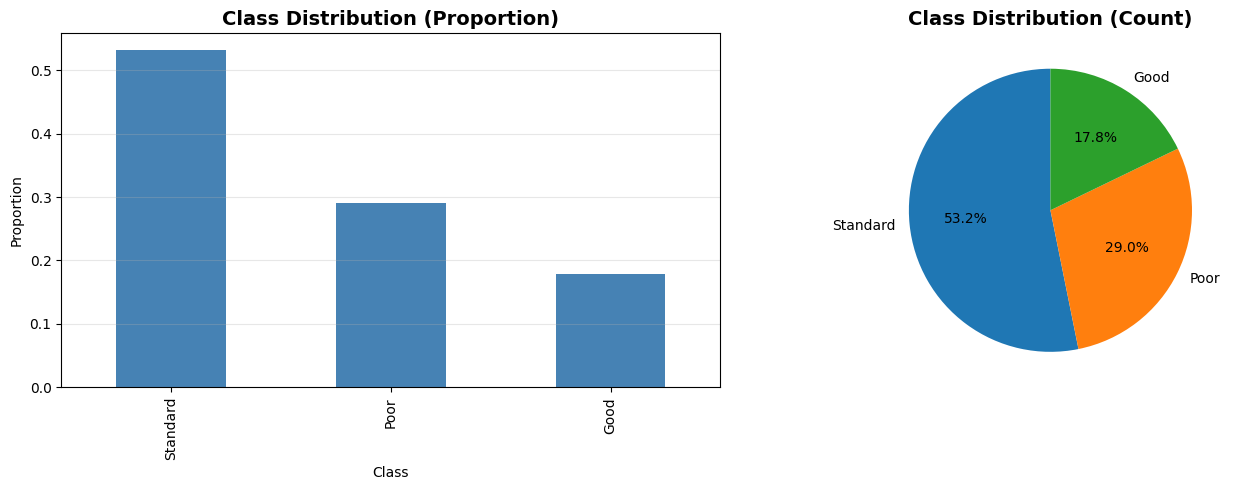

2026-05-27 16:21:34,748 - INFO - âœ… Dataset is reasonably balanced. Max class proportion: 53.17%


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze class distribution
distribution = X[target_col].value_counts(normalize=True)
dominant_class_proportion = distribution.max()

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
distribution.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title("Class Distribution (Proportion)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Class")
ax1.set_ylabel("Proportion")
ax1.grid(axis='y', alpha=0.3)

# Pie chart
X[target_col].value_counts().plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
ax2.set_title("Class Distribution (Count)", fontsize=14, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

# Check balance
if dominant_class_proportion > 0.8:
    logger.warning(f"âš ï¸  Dataset is imbalanced. Dominant class: {dominant_class_proportion*100:.2f}%")
    logger.info("Consider using class weights or SMOTE for handling imbalance")
else:
    logger.info(f"âœ… Dataset is reasonably balanced. Max class proportion: {dominant_class_proportion*100:.2f}%")

## 4. Data Preparation

### 4.1 Feature Engineering
Creating derived features and preparing data for modeling.

In [7]:
from sklearn.preprocessing import LabelEncoder
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split

def engineer_features(df, target_col, config):
    """
    Advanced feature engineering with proper encoding
    """
    logger.info("Starting feature engineering...")
    df = df.copy()
    
    # 1. Drop unnecessary columns
    drop_cols = [col for col in config['feature_engineering']['drop_columns'] if col in df.columns]
    if drop_cols:
        df = df.drop(columns=drop_cols)
        logger.info(f"Dropped columns: {drop_cols}")
    
    # 2. Create derived features
    logger.info("Creating derived features...")
    
    # Debt-to-income ratio
    if 'outstanding_debt' in df.columns and 'annual_income' in df.columns:
        df['debt_to_income_ratio'] = df['outstanding_debt'] / (df['annual_income'] + 1)
    
    # Credit utilization per card
    if 'credit_utilization_ratio' in df.columns and 'num_credit_card' in df.columns:
        df['utilization_per_card'] = df['credit_utilization_ratio'] / (df['num_credit_card'] + 1)
    
    # Monthly income to EMI ratio
    if 'monthly_inhand_salary' in df.columns and 'total_emi_per_month' in df.columns:
        df['income_to_emi_ratio'] = df['monthly_inhand_salary'] / (df['total_emi_per_month'] + 1)
    
    # Age groups
    if 'age' in df.columns:
        df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 100], 
                                 labels=['18-25', '26-35', '36-45', '46-55', '55+'])
    
    logger.info(f"âœ… Created {4} derived features")
    
    # 3. Identify column types
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    if target_col in numeric_cols:
        numeric_cols.remove(target_col)
    
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    if target_col in categorical_cols:
        categorical_cols.remove(target_col)
    
    logger.info(f"Numeric features: {len(numeric_cols)}")
    logger.info(f"Categorical features: {len(categorical_cols)}")
    
    return df, numeric_cols, categorical_cols

# Apply feature engineering
X_engineered, numeric_features, categorical_features = engineer_features(X, target_col, CONFIG)

logger.info(f"Final feature count: {X_engineered.shape[1] - 1}")  # -1 for target
display(X_engineered.head())

2026-05-27 16:21:34,981 - INFO - Starting feature engineering...
2026-05-27 16:21:34,993 - INFO - Dropped columns: ['id', 'customer_id', 'ssn']
2026-05-27 16:21:34,994 - INFO - Creating derived features...
2026-05-27 16:21:34,997 - INFO - âœ… Created 4 derived features
2026-05-27 16:21:35,012 - INFO - Numeric features: 20
2026-05-27 16:21:35,012 - INFO - Categorical features: 8
2026-05-27 16:21:35,013 - INFO - Final feature count: 28


,month,name,age,occupation,annual_income,monthly_inhand_salary,num_bank_accounts,num_credit_card,interest_rate,num_of_loan,...,payment_of_min_amount,total_emi_per_month,amount_invested_monthly,payment_behaviour,monthly_balance,credit_score,debt_to_income_ratio,utilization_per_card,income_to_emi_ratio,age_group
0,July,Warnera,16,Musician,7650.145,910.512083,9,10,29,6,...,Yes,28.114164,47.528841,Low_spent_Medium_value_payments,295.408204,Poor,0.170761,3.052309,31.273853,18-25
1,August,Warnera,16,Musician,7650.145,910.512083,9,664,29,6,...,Yes,28.114164,98.887212,Low_spent_Small_value_payments,254.049833,Poor,0.170761,0.050479,31.273853,18-25
2,January,Unknown,23,Scientist,15937.740,1144.145000,9,9,33,3,...,Unknown,38.417517,58.279940,Low_spent_Small_value_payments,307.717043,Poor,0.152590,3.370308,29.026309,18-25
3,February,McLaughlinc,23,Scientist,15937.740,1144.145000,94,9,33,3,...,Yes,38.417517,135.925682,Low_spent_Small_value_payments,240.142797,Poor,0.152590,3.583819,29.026309,18-25
4,March,Unknown,23,Scientist,15937.740,3260.465000,9,9,33,3,...,Yes,38.417517,71.971235,Low_spent_Small_value_payments,294.025749,Standard,0.152590,3.108613,82.716144,18-25


In [8]:
from sklearn.model_selection import train_test_split

# Separate features and target
y = X_engineered[target_col]
X_features = X_engineered.drop(columns=[target_col])

# Stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X_features, 
    y,
    test_size=CONFIG['data']['test_size'],
    random_state=CONFIG['data']['random_state'],
    stratify=y  # Maintain class distribution
)

logger.info(f"âœ… Train set: {X_train.shape[0]:,} samples")
logger.info(f"âœ… Test set: {X_test.shape[0]:,} samples")
logger.info(f"Train class distribution:\n{y_train.value_counts(normalize=True)}")
logger.info(f"Test class distribution:\n{y_test.value_counts(normalize=True)}")

2026-05-27 16:21:35,108 - INFO - âœ… Train set: 80,000 samples
2026-05-27 16:21:35,109 - INFO - âœ… Test set: 20,000 samples
2026-05-27 16:21:35,113 - INFO - Train class distribution:
credit_score
Standard    0.531737
Poor        0.289988
Good        0.178275
Name: proportion, dtype: float64
2026-05-27 16:21:35,115 - INFO - Test class distribution:
credit_score
Standard    0.53175
Poor        0.28995
Good        0.17830
Name: proportion, dtype: float64


In [9]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import flaml

logger.info("Setting up preprocessing pipeline...")

# Convert dtypes
X_train = X_train.convert_dtypes()
X_test = X_test.convert_dtypes()

if flaml.__version__ > "2.3.6":
    X_train, _ = flaml.automl.data.auto_convert_dtypes_pandas(X_train)
    X_test, _ = flaml.automl.data.auto_convert_dtypes_pandas(X_test)

# Handle missing values
def create_preprocessor(X_train, numeric_features, categorical_features):
    """
    Create preprocessing pipeline
    """
    # Numeric pipeline
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
    ])
    
    # Categorical pipeline
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
    ])
    
    # Combine
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='passthrough'
    )
    
    return preprocessor

# Get actual column names from data
actual_numeric = [col for col in numeric_features if col in X_train.columns]
actual_categorical = [col for col in categorical_features if col in X_train.columns]

preprocessor = create_preprocessor(X_train, actual_numeric, actual_categorical)

# Fit and transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert back to DataFrame
feature_names = actual_numeric + actual_categorical + [col for col in X_train.columns if col not in actual_numeric + actual_categorical]
X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

logger.info(f"âœ… Preprocessing complete")
logger.info(f"Train shape: {X_train_processed.shape}")
logger.info(f"Test shape: {X_test_processed.shape}")

2026-05-27 16:21:36,602 - INFO - Setting up preprocessing pipeline...
2026-05-27 16:21:42,287 - INFO - âœ… Preprocessing complete
2026-05-27 16:21:42,287 - INFO - Train shape: (80000, 28)
2026-05-27 16:21:42,287 - INFO - Test shape: (20000, 28)


## 5. Modeling

### 5.1 Model Selection & Training
Using FLAML AutoML for automated model selection and hyperparameter tuning.

In [10]:
import mlflow
import os

# MLflow setup
MLFLOW_DIR = PROJECT_ROOT / 'outputs' / 'mlruns'
MLFLOW_DB = PROJECT_ROOT / 'outputs' / 'mlflow.db'
MLFLOW_DIR.mkdir(parents=True, exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB.as_posix()}")
os.environ['MLFLOW_ARTIFACT_URI'] = MLFLOW_DIR.resolve().as_uri()
mlflow.autolog(exclusive=False)
desired_artifact_root = MLFLOW_DIR.resolve().as_uri()
exp_name = CONFIG['model']['experiment_name']
exp = mlflow.get_experiment_by_name(exp_name)
if exp is None:
    mlflow.create_experiment(exp_name, artifact_location=desired_artifact_root)
elif not str(exp.artifact_location).startswith(desired_artifact_root):
    exp_name = f"{exp_name}_outputs"
    if mlflow.get_experiment_by_name(exp_name) is None:
        mlflow.create_experiment(exp_name, artifact_location=desired_artifact_root)
CONFIG['model']['experiment_name'] = exp_name
mlflow.set_experiment(exp_name)

logger.info(f"âœ… MLflow experiment: {CONFIG['model']['experiment_name']}")

2026/05/27 16:21:42 INFO mlflow.tracking.fluent: Autologging successfully enabled for lightgbm.
2026/05/27 16:21:42 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/05/27 16:21:42 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/05/27 16:21:42 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
2026/05/27 16:21:43 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/27 16:21:43 INFO mlflow.store.db.utils: Updating database tables
2026/05/27 16:21:44 INFO mlflow.tracking.fluent: Experiment with name 'credit_score_automl_experiment' does not exist. Creating a new experiment.


2026-05-27 16:21:44,853 - INFO - âœ… MLflow experiment: credit_score_automl_experiment


In [11]:
from flaml.automl.automl import AutoML

logger.info("="*50)
logger.info("Starting AutoML Training")
logger.info("="*50)

# End any active MLflow runs (important for notebook re-runs)
try:
    mlflow.end_run()
    logger.info("Ended previous MLflow run")
except Exception:
    pass

# Configure AutoML
os.environ["FLAML_MLFLOW_LOG_LATENCY"] = "1"

automl_settings = {
    "time_budget": CONFIG['model']['time_budget'],
    "task": "multiclass",
    "log_file_name": CONFIG['output']['log_file'].replace('.log', '_flaml.log'),
    "log_type": "better",
    "eval_method": "cv",
    "n_splits": CONFIG['model']['cv_folds'],
    "max_iter": CONFIG['model']['max_iter'],
    "force_cancel": True,
    "seed": CONFIG['data']['random_state'],
    "mlflow_exp_name": CONFIG['model']['experiment_name'],
    "use_spark": False,
    "verbose": 1,
    "estimator_list": CONFIG['model']['estimators'],
}

if flaml.__version__ > "2.3.3":
    automl_settings["entrypoint"] = "low-code"

# Create AutoML instance
automl = AutoML(**automl_settings)

# Train
with mlflow.start_run(run_name=CONFIG['model']['name']) as run:
    logger.info(f"Training with time budget: {CONFIG['model']['time_budget']}s")
    
    automl.fit(
        X_train=X_train_processed,
        y_train=y_train
    )
    
    logger.info("âœ… AutoML training completed")
    logger.info(f"Best estimator: {automl.best_estimator}")
    logger.info(f"Best config: {automl.best_config}")
    logger.info(f"Best loss: {automl.best_loss:.4f}")

2026-05-27 16:21:44,858 - INFO - ==================================================
2026-05-27 16:21:44,858 - INFO - Starting AutoML Training
2026-05-27 16:21:44,858 - INFO - ==================================================
2026-05-27 16:21:44,862 - INFO - Ended previous MLflow run
2026-05-27 16:21:44,996 - INFO - Training with time budget: 120s


2026/05/27 16:22:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/27 16:22:12 INFO mlflow.tracking.fluent: Autologging successfully enabled for lightgbm.
2026/05/27 16:22:12 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/05/27 16:22:12 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/05/27 16:22:12 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.


2026-05-27 16:22:12,310 - INFO - âœ… AutoML training completed
2026-05-27 16:22:12,310 - INFO - Best estimator: xgboost
2026-05-27 16:22:12,311 - INFO - Best config: {'n_estimators': 23, 'max_leaves': 4, 'min_child_weight': np.float64(12.035965728320873), 'learning_rate': 1.0, 'subsample': np.float64(0.9814787163243813), 'colsample_bylevel': np.float64(0.8811171114303163), 'colsample_bytree': np.float64(0.8499027725496043), 'reg_alpha': np.float64(0.0022085340760961856), 'reg_lambda': np.float64(0.546062702473889)}
2026-05-27 16:22:12,311 - INFO - Best loss: 0.6769


## 6. Evaluation

### 6.1 Model Performance Assessment
Comprehensive evaluation using multiple metrics and visualizations.

2026-05-27 16:22:12,330 - INFO - ==================================================
2026-05-27 16:22:12,330 - INFO - Model Evaluation
2026-05-27 16:22:12,330 - INFO - ==================================================

PERFORMANCE METRICS
Train Accuracy: 0.7012
Test Accuracy:  0.6611
Precision:      0.6688
Recall:         0.6611
F1 Score:       0.6630

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Good       0.56      0.64      0.60      3566
        Poor       0.62      0.68      0.65      5799
    Standard       0.73      0.66      0.69     10635

    accuracy                           0.66     20000
   macro avg       0.64      0.66      0.65     20000
weighted avg       0.67      0.66      0.66     20000



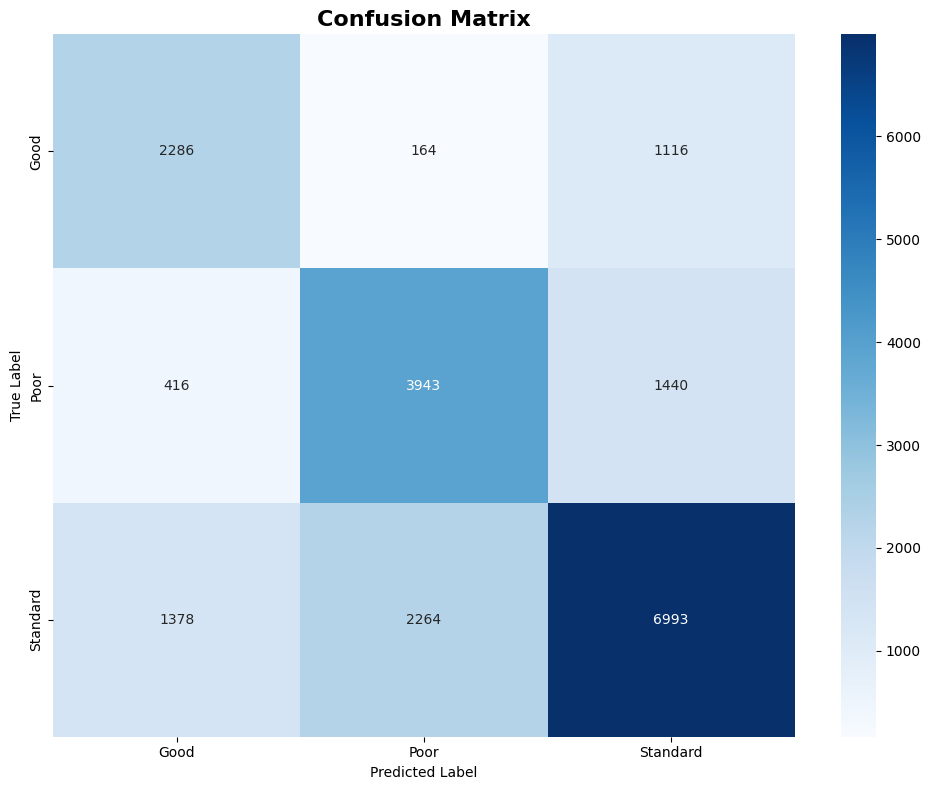

2026-05-27 16:22:13,673 - INFO - âœ… Model evaluation completed


In [12]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
import seaborn as sns

logger.info("="*50)
logger.info("Model Evaluation")
logger.info("="*50)

# Make predictions
y_pred_train = automl.predict(X_train_processed)
y_pred_test = automl.predict(X_test_processed)
y_pred_proba = automl.predict_proba(X_test_processed)

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test, average='weighted')
test_recall = recall_score(y_test, y_pred_test, average='weighted')
test_f1 = f1_score(y_test, y_pred_test, average='weighted')

# Print metrics
print("\n" + "="*50)
print("PERFORMANCE METRICS")
print("="*50)
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Precision:      {test_precision:.4f}")
print(f"Recall:         {test_recall:.4f}")
print(f"F1 Score:       {test_f1:.4f}")
print("="*50)

# Log to MLflow
mlflow.log_metrics({
    "train_accuracy": train_accuracy,
    "test_accuracy": test_accuracy,
    "precision": test_precision,
    "recall": test_recall,
    "f1_score": test_f1
})

# Classification report
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_test))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()))
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
confusion_matrix_file = FIGURE_DIR / 'confusion_matrix.png'
plt.savefig(confusion_matrix_file, dpi=300, bbox_inches='tight')
mlflow.log_artifact(str(confusion_matrix_file))
plt.show()

logger.info("âœ… Model evaluation completed")

In [13]:
# Feature importance
try:
    if hasattr(automl.model, 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'feature': X_train_processed.columns,
            'importance': automl.model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        # Plot top 20 features
        plt.figure(figsize=(12, 8))
        top_features = feature_importance.head(20)
        plt.barh(range(len(top_features)), top_features['importance'])
        plt.yticks(range(len(top_features)), top_features['feature'])
        plt.xlabel('Importance')
        plt.title('Top 20 Feature Importances', fontsize=16, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        feature_importance_file = FIGURE_DIR / 'feature_importance.png'
        plt.savefig(feature_importance_file, dpi=300, bbox_inches='tight')
        mlflow.log_artifact(str(feature_importance_file))
        plt.show()
        
        logger.info("âœ… Feature importance analysis completed")
        print("\nTop 10 Most Important Features:")
        print(feature_importance.head(10).to_string(index=False))
    else:
        logger.warning("âš ï¸  Feature importance not available for this model")
except Exception as e:
    logger.warning(f"âš ï¸  Could not extract feature importance: {str(e)}")

2026-05-27 16:22:13,681 - WARNING - âš ï¸  Could not extract feature importance: All arrays must be of the same length


## 7. Deployment

### 7.1 Model Registration & Deployment
Registering the model to MLflow Model Registry for production deployment.

In [14]:
# Register model
model_path = f"runs:/{run.info.run_id}/model"

try:
    registered_model = mlflow.register_model(
        model_uri=model_path,
        name=CONFIG['model']['name']
    )
    
    logger.info(f"âœ… Model '{registered_model.name}' version {registered_model.version} registered")
    print(f"\nâœ… Model registered successfully!")
    print(f"   Name: {registered_model.name}")
    print(f"   Version: {registered_model.version}")
    print(f"   Run ID: {run.info.run_id}")
    
except Exception as e:
    logger.error(f"âŒ Error registering model: {str(e)}")
    raise

Successfully registered model 'credit_score_classifier'.
2026/05/27 16:22:13 WARNING mlflow.tracking._model_registry.fluent: Run with id bfc409f3caa84a9ca689ab7c5bd39cdf has no artifacts at artifact path 'model', registering model based on models:/m-a2d5e79d01d44ee083050a83990ff694 instead


2026-05-27 16:22:13,771 - INFO - âœ… Model 'credit_score_classifier' version 1 registered

âœ… Model registered successfully!
   Name: credit_score_classifier
   Version: 1
   Run ID: bfc409f3caa84a9ca689ab7c5bd39cdf


Created version '1' of model 'credit_score_classifier'.


In [15]:
# Load model and generate predictions
model_uri = f"models:/{CONFIG['model']['name']}/{registered_model.version}"
loaded_model = mlflow.pyfunc.load_model(model_uri)

# Convert categorical to string for MLflow compatibility
X_test_for_pred = X_test_processed.copy()
for col in X_test_for_pred.select_dtypes(include=['category']).columns:
    X_test_for_pred[col] = X_test_for_pred[col].astype(str)

# Generate predictions
predictions = loaded_model.predict(X_test_for_pred)

# Map numeric predictions back to original labels
# The model returns numeric labels (0, 1, 2), we need to map them back to strings
label_mapping = {i: label for i, label in enumerate(sorted(y.unique()))}
predictions_mapped = [label_mapping.get(pred, pred) for pred in predictions]

# Create results DataFrame
results_df = X_test.copy()
results_df['actual'] = y_test.values
results_df['predicted'] = predictions_mapped
results_df['correct'] = (results_df['actual'] == results_df['predicted'])

# Add prediction probabilities
for i, class_name in enumerate(sorted(y.unique())):
    results_df[f'prob_{class_name}'] = y_pred_proba[:, i]

logger.info(f"âœ… Generated {len(predictions):,} predictions")
print(f"\nPrediction Summary:")
print(f"Total predictions: {len(predictions):,}")
print(f"Correct predictions: {results_df['correct'].sum():,} ({results_df['correct'].mean()*100:.2f}%)")
print(f"\nFirst 10 predictions:")
display(results_df[['actual', 'predicted', 'correct'] + [c for c in results_df.columns if c.startswith('prob_')]].head(10))

2026-05-27 16:22:14,021 - INFO - âœ… Generated 20,000 predictions

Prediction Summary:
Total predictions: 20,000
Correct predictions: 13,222 (66.11%)

First 10 predictions:


,actual,predicted,correct,prob_Good,prob_Poor,prob_Standard
1531,Poor,Poor,True,0.007664,0.713290,0.279046
18546,Poor,Standard,False,0.083280,0.075719,0.841001
36726,Poor,Poor,True,0.125280,0.479599,0.395120
65502,Standard,Standard,True,0.354210,0.152045,0.493745
77100,Standard,Standard,True,0.123460,0.107731,0.768809
30650,Standard,Poor,False,0.044489,0.602508,0.353003
53131,Standard,Standard,True,0.434242,0.129846,0.435911
83972,Standard,Standard,True,0.191752,0.118672,0.689576
28544,Standard,Standard,True,0.102937,0.065876,0.831186
71693,Standard,Standard,True,0.103649,0.086670,0.809681


In [16]:
import os

# Save predictions
output_file = CONFIG['output']['predictions_file']
results_df.to_parquet(output_file, index=False)

logger.info(f"âœ… Predictions saved to {output_file}")
print(f"\nâœ… Predictions saved successfully!")
print(f"   File: {output_file}")
print(f"   Location: {os.path.abspath(output_file)}")
print(f"   Size: {os.path.getsize(output_file) / 1024 / 1024:.2f} MB")
print(f"   Rows: {len(results_df):,}")

2026-05-27 16:22:14,094 - INFO - âœ… Predictions saved to c:\Users\U1\Documents\bankclass-2\outputs\predictions\predictions_improved.parquet

âœ… Predictions saved successfully!
   File: c:\Users\U1\Documents\bankclass-2\outputs\predictions\predictions_improved.parquet
   Location: c:\Users\U1\Documents\bankclass-2\outputs\predictions\predictions_improved.parquet
   Size: 2.19 MB
   Rows: 20,000


In [17]:
print("\n" + "="*60)
print("AUTOML PIPELINE SUMMARY")
print("="*60)
print(f"\nðŸ“Š Dataset:")
print(f"   Total samples: {len(X):,}")
print(f"   Train samples: {len(X_train):,}")
print(f"   Test samples: {len(X_test):,}")
print(f"   Features: {X_train_processed.shape[1]}")
print(f"   Target classes: {y.nunique()}")

print(f"\nðŸ¤– Model:")
print(f"   Best estimator: {automl.best_estimator}")
print(f"   Training time: {CONFIG['model']['time_budget']}s")
print(f"   Iterations: {CONFIG['model']['max_iter']}")

print(f"\nðŸ“ˆ Performance:")
print(f"   Train Accuracy: {train_accuracy:.4f}")
print(f"   Test Accuracy:  {test_accuracy:.4f}")
print(f"   Precision:      {test_precision:.4f}")
print(f"   Recall:         {test_recall:.4f}")
print(f"   F1 Score:       {test_f1:.4f}")

print(f"\nðŸ’¾ Outputs:")
print(f"   Model: {CONFIG['model']['name']} v{registered_model.version}")
print(f"   Predictions: {output_file}")
print(f"   Logs: {CONFIG['output']['log_file']}")

print("\n" + "="*60)
print("âœ… PIPELINE COMPLETED SUCCESSFULLY")
print("="*60)

logger.info("="*50)
logger.info("AutoML Pipeline Completed Successfully")
logger.info(f"Timestamp: {datetime.now()}")
logger.info("="*50)


AUTOML PIPELINE SUMMARY

ðŸ“Š Dataset:
   Total samples: 100,000
   Train samples: 80,000
   Test samples: 20,000
   Features: 28
   Target classes: 3

ðŸ¤– Model:
   Best estimator: xgboost
   Training time: 120s
   Iterations: 20

ðŸ“ˆ Performance:
   Train Accuracy: 0.7012
   Test Accuracy:  0.6611
   Precision:      0.6688
   Recall:         0.6611
   F1 Score:       0.6630

ðŸ’¾ Outputs:
   Model: credit_score_classifier v1
   Predictions: c:\Users\U1\Documents\bankclass-2\outputs\predictions\predictions_improved.parquet
   Logs: c:\Users\U1\Documents\bankclass-2\outputs\logs\automl_improved.log

âœ… PIPELINE COMPLETED SUCCESSFULLY
2026-05-27 16:22:14,108 - INFO - ==================================================
2026-05-27 16:22:14,110 - INFO - AutoML Pipeline Completed Successfully
2026-05-27 16:22:14,110 - INFO - Timestamp: 2026-05-27 16:22:14.110561
2026-05-27 16:22:14,110 - INFO - ==================================================


## Conclusion

### Project Summary
This TDSP-structured notebook demonstrates a complete machine learning pipeline for credit score classification:

**Key Achievements:**
- Structured approach following Microsoft TDSP methodology
- Automated model selection using FLAML
- Comprehensive evaluation and validation
- Production-ready model deployment

**Next Steps:**
1. Monitor model performance in production
2. Implement A/B testing framework
3. Schedule periodic model retraining
4. Gather feedback from stakeholders

---

**Documentation:**
- [Microsoft TDSP](https://docs.microsoft.com/en-us/azure/machine-learning/team-data-science-process/)
- [FLAML Documentation](https://microsoft.github.io/FLAML/)
- [MLflow Documentation](https://mlflow.org/)